In [1]:

pip install tensorflow  


Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



In [2]:
# =========================
# XGBOOST - LITHOLOGY PREDICTION
# =========================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

from xgboost import XGBClassifier

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Downloads/G43.csv")
df.head()

,TopDepth,BotDepth,_CAL,_GR,_SP,_LLD,_LLS,_AC,_DEN,_PEF,Lith_Section
0,1205.01,1209.52,9.20954,70.5714,-2.73128,6.33422,5.53460,96.5559,2.37177,0.345610,mudstone
1,1209.52,1213.01,9.04982,86.7602,-3.98493,14.05870,15.38260,98.9526,2.28490,0.342784,silty mudstone
2,1213.01,1217.96,8.81076,130.3960,-2.41882,39.76830,52.32880,105.6720,2.20369,0.338436,oil shale
3,1217.96,1219.92,10.18560,105.6910,-2.05301,3.60914,4.55261,112.6560,1.97517,0.341624,mudstone
4,1219.92,1220.94,9.61562,118.1890,-4.19831,7.06118,6.68929,117.6270,2.16025,0.343647,mudstone


In [4]:
# Step 3: Features & Target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [5]:
# Step 4: Handle Missing Values
X = X.fillna(X.mean())

In [6]:
# Step 5: Encode Target
le = LabelEncoder()
y_enc = le.fit_transform(y)

In [7]:
# Step 6: Train XGBoost Model (FULL DATA)
model = XGBClassifier(
    n_estimators=200,   # number of trees
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X, y_enc)

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:183: UserWarning: [11:10:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
# Step 7: Prediction
y_pred = model.predict(X)

In [9]:
# Step 8: Accuracy
acc = accuracy_score(y_enc, y_pred)
print("XGBoost Accuracy:", acc)

XGBoost Accuracy: 1.0


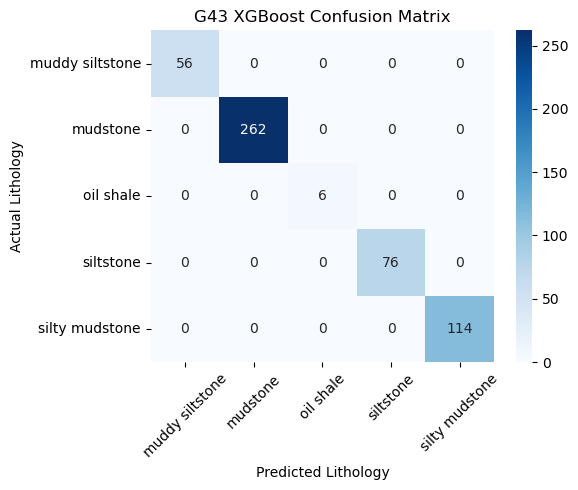

In [11]:
# Step 9: Confusion Matrix
cm = confusion_matrix(y_enc, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',   # normal numbers (no scientific notation)
            cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("G43 XGBoost Confusion Matrix")
plt.xlabel("Predicted Lithology")
plt.ylabel("Actual Lithology")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()